# CPC Comparison vs Standard Constrained Bayesian Optimization on Townsend Test Function — Plotting Only (from CSV results)

This notebook re-creates the summary figures produced by `cpc_cbo.py`
**directly from the saved CSV result files**, so you can re-plot without re-running
any experiments.

Each experiment writes two long-format CSVs into the `results/` directory:

* `Objective_*.csv`  — best-objective-value-over-time panel
  (columns: `temperature, method, iteration, regret_mean, regret_std, best_obj_mean, best_obj_se`)
* `Constraint_*.csv` — per-round-constraint-violations panel
  (columns: `temperature, method, iteration, violations_per_round_mean, violations_per_round_std, violations_per_round_se`)

Set experiment config params (n_trials, cpc_alphas, temps) to those corresponding to CSV results files you want to plot. Set `INCLUDE_GAUSSIAN = True` to also plot the Gaussian Random baseline.

In [1]:
from cpc_cbo_plot_utils import _savefig_tight_subplot, plot_results_from_csv


## Configuration

Choose the two CSV files (one objective, one constraint) that came from the **same**
run, and whether to include the Gaussian Random baseline.

In [2]:
# Include the Gaussian Random (Safe Policy) baseline in the plots?
INCLUDE_GAUSSIAN = True

# Shade the +/- standard-error bands stored in the CSVs?
SHOW_SE = True

# Directory that holds the CSV result files. Will also be location used to save plots.
SAVE_DIR = 'results'


# Experiment parameters: Set these to match CSV results files you want to plot.
n_trials = 100
cpc_alphas = [0.4]
temps = [2.0, 1.0, 0.1]


## Generate the plots

Run the cell below to render the figure from the configured CSV files.

In [3]:
# Plot results

for alpha in cpc_alphas:
    for temp in temps:
        fig, ax_con, ax_obj, fig_legend = plot_results_from_csv(
            objective_csv=os.path.join(SAVE_DIR, f"Objective_temp{temp}_alpha{alpha}_nTrials{n_trials}.csv"),
            constraint_csv=os.path.join(SAVE_DIR, f"Constraint_temp{temp}_alpha{alpha}_nTrials{n_trials}.csv"),
            include_gaussian=INCLUDE_GAUSSIAN,
            show_se=SHOW_SE,
            save_dir=SAVE_DIR,
        )

        _savefig_tight_subplot(ax_obj, f'./{SAVE_DIR}/Objective_temp{temp}_alpha{alpha}_nTrials{n_trials}.pdf', pad_inches=0.12, dpi=300)
        _savefig_tight_subplot(ax_con, f'./{SAVE_DIR}/Constraint_temp{temp}_alpha{alpha}_nTrials{n_trials}.pdf', pad_inches=0.12, dpi=300)
        
        plt.show()

NameError: name 'os' is not defined

## Plot Townsend objective with Gaussian PDF overlay


In [ ]:
import torch
torch.set_default_dtype(torch.float64)
tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
    # "device": torch.device("cpu")
}

class Townsend:
    def __init__(self):
        self.dim = 2
        # Domain box from the canonical Chebfun definition of the Townsend
        # (constrained) problem: chebfun2(@(x,y) ..., [-3 3 -3 3]), i.e. both
        # coordinates range over [-3, 3].
        # (See https://www.chebfun.org/examples/opt/ConstrainedOptimization.html)
        self.lower = torch.tensor([-3.0, -3.0], **tkwargs)
        self.upper = torch.tensor([3.0, 3.0], **tkwargs)
        # botorch normalize/unnormalize expect bounds of shape (2, dim) with
        # row 0 = per-dim lower and row 1 = per-dim upper.
        self.bounds = torch.stack([self.lower, self.upper])
        self._optimal_value = 2.024 #1.660
        self.name = "Townsend"

    def __call__(self, x):
        return self.objective(x)

    def is_feasible(self, x):
        x1, x2 = x[..., 0], x[..., 1]
        t = torch.atan2(x1, x2)
        c = ((2 * torch.cos(t) - 0.5 * torch.cos(2 * t) - 0.25 * torch.cos(3 * t) - 0.125 * torch.cos(4 * t)) ** 2 + (2 * torch.sin(t)) ** 2 - x1 ** 2 - x2 ** 2)
        y_con = (c > 0).float()  # binarize the feasibility
        return y_con

    def objective(self, x):
        x1, x2 = x[..., 0], x[..., 1]
        return torch.cos((x1 - 0.1) * x2) ** 2 + x1 * torch.sin(3 * x1 + x2)



townsend = Townsend()

In [ ]:
# Plot the townsend function and constraint
import matplotlib.pyplot as plt
import numpy as np

GAUSSIAN_STD_DIV_FACTOR = 6.5
GAUSSIAN_MEAN = torch.tensor([0, -1.0], **tkwargs)


def plot_townsend(ax):
    x = np.linspace(-3.0, 3.0, 100)
    y = np.linspace(-3.0, 3.0, 100)
    X, Y = np.meshgrid(x, y)

    obj = townsend(torch.tensor(np.stack([X, Y], axis=-1), **tkwargs)).cpu().numpy()
    con = townsend.is_feasible(torch.tensor(np.stack([X, Y], axis=-1), **tkwargs)).cpu().numpy()

    # mask out the constraint region < 0
    obj[con == 0] = np.nan

    c = ax.contourf(X, Y, obj, levels=20, cmap="Blues")

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("Townsend Problem")

    plt.colorbar(c, ax=ax, orientation="vertical")
    return ax


# Multivariate Gaussian PDF Function
def gaussian_pdf(x, mean=GAUSSIAN_MEAN, std=None):
    """
    Evaluate the multivariate Gaussian probability density function at point(s) x.
    Uses the same default parameters as generate_gaussian_samples().
    
    Args:
        x: Point(s) to evaluate PDF at. Shape: [n_points, dim] or [dim]
        mean: Mean of the Gaussian (default: center of search space)
        std: Standard deviation per dimension (default: 1/6 of search space range)
    
    Returns:
        pdf_values: PDF value(s) at x. Shape: [n_points] or scalar
    
    Formula:
        For diagonal covariance (independent dimensions):
        p(x) = ∏_i (1/√(2πσ_i²)) * exp(-0.5 * ((x_i - μ_i)/σ_i)²)
    """
    # Handle single point vs batch
    if x.dim() == 1:
        x = x.unsqueeze(0)
        squeeze_output = True
    else:
        squeeze_output = False
    
    # Default mean: center of the search space
    if mean is None:
        mean = (townsend.bounds[0] + townsend.bounds[1]) / 2
    
    # Default std: 1/6 of range (so 3*std covers most of the space)
    if std is None:
        range_per_dim = townsend.bounds[1] - townsend.bounds[0]
        std = range_per_dim / GAUSSIAN_STD_DIV_FACTOR
    
    # Compute PDF for diagonal covariance (independent dimensions)
    # Log probability for numerical stability
    log_pdf = torch.zeros(x.shape[0], **tkwargs)
    
    for dim in range(x.shape[1]):
        # Normalization constant: log(1/√(2πσ²))
        log_norm = -0.5 * torch.log(2 * torch.tensor(torch.pi, **tkwargs)) - torch.log(std[dim])
        
        # Exponential term: -0.5 * ((x - μ)/σ)²
        standardized = (x[:, dim] - mean[dim]) / std[dim]
        log_exp = -0.5 * standardized ** 2
        
        log_pdf += log_norm + log_exp
    
    # Convert back from log space
    pdf_values = torch.exp(log_pdf)
    
    if squeeze_output:
        return pdf_values.squeeze()
    
    return pdf_values

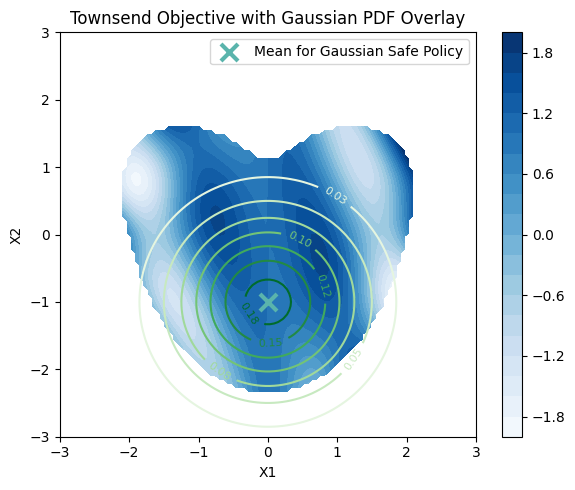

In [ ]:

TEAL = '#5ab4ac'           # Calibration data (complements blue/red)


# Superimpose the Townsend objective and the Gaussian PDF on a 2D plot
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Townsend objective (feasible region only) as filled contours
plot_townsend(ax)

mean = GAUSSIAN_MEAN

# Evaluate the Gaussian PDF on the same grid
x = np.linspace(-3.0, 3.0, 100)
y = np.linspace(-3.0, 3.0, 100)
X, Y = np.meshgrid(x, y)
grid_points = torch.tensor(np.stack([X, Y], axis=-1), **tkwargs).reshape(-1, 2)
pdf_grid = gaussian_pdf(grid_points).reshape(100, 100).cpu().numpy()

# Overlay the Gaussian PDF as contour lines
pdf_contours = ax.contour(X, Y, pdf_grid, levels=8, cmap="Greens", linewidths=1.5)
ax.clabel(pdf_contours, inline=True, fontsize=8, fmt="%.2f")

# Mark the Gaussian mean
# mean = (townsend.bounds[0] + townsend.bounds[1]) / 2

ax.scatter(mean[0].cpu(), mean[1].cpu(), color=TEAL, marker="x", s=150,
           linewidth=3, label="Mean for Gaussian Safe Policy", zorder=10)

ax.set_title("Townsend Objective with Gaussian PDF Overlay")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f'./{SAVE_DIR}/Townsend_Gaussian_PDF_Overlay.pdf', dpi=300)
plt.show()